# Лабораторная работа № 3

# Предварительная обработка данных

**Цель работы:** познакомиться с теоретическими принципами и инструментальными средствами предварительной обработки данных.

Проанализируем датасет auto1. Датасет содержит данные об автомобилях. Признаки включают технические характеристики, а также категориальные атрибуты. Данные предназначены для задач регрессии (прогнозирование топливной эффективности) или анализа влияния конструктивных параметров на расход топлива. Набор данных включает следующие атрибуты:
- **mpg** – расход топлива (miles per gallon);
- **cylinders** – цилиндры;
- **displacement** – пробег;
- **horsepower** – мощность двигателя в л.с.;
- **weight** – вес;
- **acceleration** – ускорение;
- **model** – год выпуска;
- **origin** – происхождение (1 – США, 2 – Европа, 3 – Япония);
- **car** – название модели.

# 0. Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем набор данных из файла auto1.csv и помещаем его в объект DataFrame

In [2]:
df = pd.read_csv('auto1.csv')

# 2. Выведем 5 первых строк

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,18.0,8,307,130,3504,12.0,70,1,chevrolet chevelle malibu,NaN,NaN,NaN,NaN,NaN
1,15.0,8,350,165,3693,11.5,70,1,buick skylark 320,NaN,NaN,NaN,NaN,NaN
2,18.0,8,318,150,3436,11.0,70,1,plymouth satellite,NaN,NaN,NaN,NaN,NaN
3,16.0,8,304,150,3433,12.0,70,1,amc rebel sst,NaN,NaN,NaN,NaN,NaN
4,17.0,8,302,140,3449,10.5,70,1,ford torino,NaN,NaN,NaN,NaN,NaN


Видим, что в датасете присутствуют 5 лишних столбцов (Unnamed: 9–13), которые полностью состоят из пустых значений (NaN). Удалим их.

In [4]:
df = df.dropna(axis=1, how='all')

Выведем первые 5 строк очищенного датафрейма.

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car
0,18.0,8,307,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302,140,3449,10.5,70,1,ford torino


# 3. Базовые методы обнаружения пропущенных значений

## Метод .info()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           198 non-null    float64
 1   cylinders     198 non-null    int64  
 2   displacement  198 non-null    int64  
 3   horsepower    198 non-null    object 
 4   weight        198 non-null    int64  
 5   acceleration  198 non-null    float64
 6   model         198 non-null    int64  
 7   origin        198 non-null    int64  
 8   car           198 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 14.1+ KB


> Всего в датасете 198 записей и 9 столбцов. Метод .info() показывает, что во всех столбцах 198 non-null значений, то есть формально пропусков нет. Типы данных: float64 (2 столбца), int64 (5 столбцов), object (2 столбца — horsepower и car).

## Методы .isna() и .sum()

In [7]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model           0
origin          0
car             0
dtype: int64

> Метод .isna().sum() показывает 0 пропусков во всех столбцах. Однако видно, что столбец horsepower имеет тип object, хотя мощность двигателя — это числовой признак. Значит, в столбце могут содержаться нечисловые значения, которые мешают pandas определить тип как числовой.

Проверим, нет ли в столбце horsepower нечисловых значений, для этого выведем все уникальные значения этого столбца.

In [8]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152'],
      dtype=object)

> Среди уникальных значений столбца horsepower обнаружен символ '?'. Именно из-за него pandas определил тип столбца как object.

 Заменим '?' на NaN и преобразуем столбец в числовой тип.

In [9]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype('float64')

Проверим количество пропусков после замены.

In [10]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      2
weight          0
acceleration    0
model           0
origin          0
car             0
dtype: int64

> Теперь метод .isna().sum() корректно показывает 2 пропущенных значения в столбце horsepower. В остальных столбцах пропусков нет.

## Процент пропущенных значений

In [11]:
(df.isna().sum() / len(df)).round(4) * 100

mpg             0.00
cylinders       0.00
displacement    0.00
horsepower      1.01
weight          0.00
acceleration    0.00
model           0.00
origin          0.00
car             0.00
dtype: float64

> Процент единственных пропущенных значений в столбце horsepower составляет 1.01%.

## Матрица корреляции пропущенных значений

Матрица корреляции пропущенных значений показывает, насколько сильно присутствие или отсутствие значений одного признака влияет на присутствие значений другого. В моём датасете пропуски содержатся только в одном столбце — horsepower, поэтому построить матрицу корреляции пропусков невозможно (для этого нужно минимум 2 столбца с пропусками).

# 4. Стратегии работы с пропусками

## Удаление строк

В столбце horsepower только 2 пропущенных значения (1.01%). Это небольшой процент, поэтому можно удалить соответствующие строки без значительной потери данных.

In [12]:
df.dropna(axis='index', subset=['horsepower'], inplace=True)

Проверяем, что в столбце horsepower больше не осталось пропусков.

In [13]:
df.horsepower.isna().sum()

np.int64(0)

## Удаление столбцов

Удаление столбцов применяется, когда в столбце большой процент пропусков (например, более 50%). В моем датасете пропуски содержатся только в столбце horsepower и составляют 1.01%, поэтому удалять столбцы нет необходимости.

## Заполнение пропусков

Рассмотрим различные способы заполнения пропусков. Для этого заново загрузим датасет и подготовим данные.

In [14]:
df = pd.read_csv('auto1.csv', usecols=range(9))
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype('float64')

### Заполнение константой

In [15]:
fillna_const = df.copy()
fillna_const.fillna({'horsepower' : 0}, inplace=True)

Сравним медианное значение мощности до и после заполнения пропусков нулями.

In [16]:
df.horsepower.median(), fillna_const.horsepower.median()

(100.0, 100.0)

> Медианное значение мощности до заполнения — 100.0, после заполнения нулями — 100.0. В моем случае медиана не изменилась, так как пропусков всего 2 из 198 записей. Однако заполнение константой может внести системную ошибку в данные, особенно если пропусков много.

### Заполнение средним арифметическим

In [17]:
fillna_mean = df.copy()
fillna_mean['horsepower'] = fillna_mean.horsepower.fillna(fillna_mean.horsepower.mean())

Сравним среднее арифметическое значение мощности до и после заполнения пропусков средним арифметическим.

In [18]:
df.horsepower.mean(), fillna_mean.horsepower.mean()

(np.float64(116.24489795918367), np.float64(116.24489795918366))

> Среднее арифметическое значение мощности до и после заполнения — 116.24. Значение не изменилось, так как пропуски были заполнены именно средним арифметическим.

### Заполнение медианой

In [19]:
fillna_median = df.copy()
fillna_median['horsepower'] = fillna_median.horsepower.fillna(fillna_median.horsepower.median())

Сравним медианное значение мощности до и после заполнения пропусков медианой.

In [20]:
df.horsepower.median(), fillna_median.horsepower.median()

(100.0, 100.0)

> Медианное значение мощности до и после заполнения медианой — 100.0. Медиана не изменилась, так как пропуски были заполнены именно медианным значением. Этот способ, также как и заполнение средним арифметическим не искажает центральную тенденцию данных, но снижает вариативность.

### Заполнение наиболее частотным значением

Для заполнения пропусков в категориальных данных подойдет метод заполнения наиболее часто встречающимся значением (модой). В моём датасете пропусков в категориальных столбцах нет, поэтому продемонстрируем этот метод на столбце horsepower.

In [21]:
fillna_mode = df.copy()
mode_value = fillna_mode['horsepower'].mode()[0]
fillna_mode['horsepower'] = fillna_mode['horsepower'].fillna(mode_value)

Сравним медианное значение мощности до и после заполнения пропусков модой.

In [22]:
df.horsepower.median(), fillna_mode.horsepower.median()

(100.0, 100.0)

> Медианное значение мощности до и после заполнения модой — 100.0. Медиана не изменилась, так как пропусков всего 2 из 198 записей, и их заполнение практически не влияет на распределение данных.

# 5. Кодирование категориальных переменных

In [23]:
df = fillna_mode.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           198 non-null    float64
 1   cylinders     198 non-null    int64  
 2   displacement  198 non-null    int64  
 3   horsepower    198 non-null    float64
 4   weight        198 non-null    int64  
 5   acceleration  198 non-null    float64
 6   model         198 non-null    int64  
 7   origin        198 non-null    int64  
 8   car           198 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 14.1+ KB


> В датафрейме 198 записей, пропусков нет. Столбец car имеет тип object — это текстовый категориальный признак (название модели). Столбец origin имеет тип int64, но по смыслу является категориальным (1 — США, 2 — Европа, 3 — Япония).

Отдельные категории можно посмотреть с помощью метода .unique().

In [24]:
df.origin.unique()

array([1, 3, 2])

С помощью методов .value_counts() библиотеки Pandas и np.unique() библиотеки Numpy можно посмотреть и количество объектов в каждой категории.

In [25]:
df.origin.value_counts()

origin
1    136
2     37
3     25
Name: count, dtype: int64

> В датасете преобладают автомобили из США (origin = 1) — 136 штук. Из Европы (origin = 2) — 37, из Японии (origin = 3) — 25.

In [26]:
np.unique(df.origin, return_counts=True)

(array([1, 2, 3]), array([136,  37,  25]))

Последовательное применение методов .value_counts() и .count() выведет общее количество уникальных категорий.

In [27]:
df.origin.value_counts().count()

np.int64(3)

Выведем категории на графике.

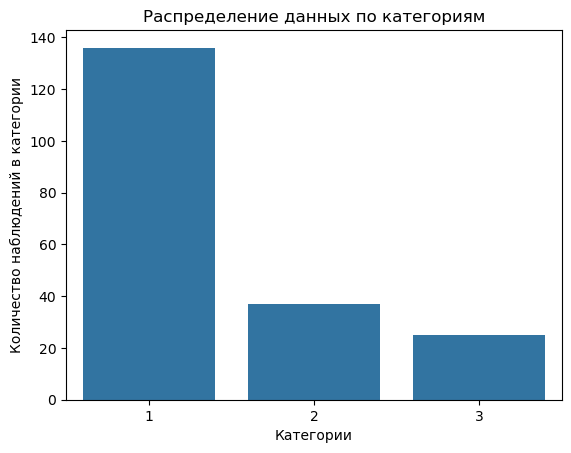

In [28]:
origin_counts = df.origin.value_counts()
sns.barplot(x=origin_counts.index, y=origin_counts.values)
plt.title('Распределение данных по категориям')
plt.ylabel('Количество наблюдений в категории')
plt.xlabel('Категории');

## Тип данных category

Преобразуем столбец origin из типа int64 в тип category, чтобы pandas воспринимал его как категориальный признак.

In [29]:
df = df.astype({'origin' : 'category'})

Убедимся, что нужные нам признаки преобразованы в тип category.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           198 non-null    float64 
 1   cylinders     198 non-null    int64   
 2   displacement  198 non-null    int64   
 3   horsepower    198 non-null    float64 
 4   weight        198 non-null    int64   
 5   acceleration  198 non-null    float64 
 6   model         198 non-null    int64   
 7   origin        198 non-null    category
 8   car           198 non-null    object  
dtypes: category(1), float64(3), int64(4), object(1)
memory usage: 12.8+ KB


## Базовые методы кодирования

### Кодирование через cat.codes

Кодировать категориальную переменную можно через атрибут cat.codes.

In [31]:
df_cat = df.copy()
df_cat.origin.cat.codes

0      0
1      0
2      0
3      0
4      0
      ..
193    0
194    0
195    0
196    0
197    1
Length: 198, dtype: int8

Применим коды к столбцу origin и выведем датафрейм.

In [32]:
df_cat.origin = df_cat.origin.cat.codes
df_cat

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car
0,18.0,8,307,130.0,3504,12.0,70,0,chevrolet chevelle malibu
1,15.0,8,350,165.0,3693,11.5,70,0,buick skylark 320
2,18.0,8,318,150.0,3436,11.0,70,0,plymouth satellite
3,16.0,8,304,150.0,3433,12.0,70,0,amc rebel sst
4,17.0,8,302,140.0,3449,10.5,70,0,ford torino
...,...,...,...,...,...,...,...,...,...
193,24.0,6,200,81.0,3012,17.6,76,0,ford maverick
194,22.5,6,232,90.0,3085,17.6,76,0,amc hornet
195,29.0,4,85,52.0,2035,22.2,76,0,chevrolet chevette
196,24.5,4,98,60.0,2164,22.1,76,0,chevrolet woody


> Столбец origin закодирован числовыми кодами: 0 — США (было 1), 1 — Европа (было 2), 2 — Япония (было 3). Коды присваиваются автоматически в порядке возрастания исходных значений.

## Mapping

Суть способа в том, чтобы передать схему кодирования в виде словаря в функцию map() и применить к соответствующему столбцу.

In [33]:
df_map = df.copy()
map_dict = {1 : 0,
            2 : 1,
            3 : 2}
df_map['origin'] = df_map['origin'].map(map_dict)
df_map

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car
0,18.0,8,307,130.0,3504,12.0,70,0,chevrolet chevelle malibu
1,15.0,8,350,165.0,3693,11.5,70,0,buick skylark 320
2,18.0,8,318,150.0,3436,11.0,70,0,plymouth satellite
3,16.0,8,304,150.0,3433,12.0,70,0,amc rebel sst
4,17.0,8,302,140.0,3449,10.5,70,0,ford torino
...,...,...,...,...,...,...,...,...,...
193,24.0,6,200,81.0,3012,17.6,76,0,ford maverick
194,22.5,6,232,90.0,3085,17.6,76,0,amc hornet
195,29.0,4,85,52.0,2035,22.2,76,0,chevrolet chevette
196,24.5,4,98,60.0,2164,22.1,76,0,chevrolet woody


> Столбец origin закодирован с помощью словаря: 1 → 0 (США), 2 → 1 (Европа), 3 → 2 (Япония). Результат аналогичен кодированию через cat.codes, но здесь мы сами задаём схему кодирования.

## OneHotEncoding

Применим метод OneHotEncoding к столбцу origin для кодирования номинальных данных.

In [34]:
df_enc = df.copy()
from sklearn.preprocessing import OneHotEncoder

# Создаем энкодер для кодирования столбца origin
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Применяем энкодер к столбцу origin
encoded_array = encoder.fit_transform(df_enc[['origin']])

# Создаем датафрейм с новыми столбцами origin_1, origin_2, origin_3
df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['origin'])
)
df_encoded.head()

,origin_1,origin_2,origin_3
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


> Выведены первые 5 строк закодированного датафрейма. Все 5 автомобилей относятся к категории origin_1 (США), поэтому в столбце origin_1 стоит 1.0, а в остальных (origin_2 и origin_3) — 0.0.

Присоединим новые признаки к исходному датафрейму, удалив признак origin.

In [35]:
df_onehot = df_enc.join(df_encoded)
df_onehot.drop('origin', axis=1, inplace=True)

In [36]:
df_onehot.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,car,origin_1,origin_2,origin_3
0,18.0,8,307,130.0,3504,12.0,70,chevrolet chevelle malibu,1.0,0.0,0.0
1,15.0,8,350,165.0,3693,11.5,70,buick skylark 320,1.0,0.0,0.0
2,18.0,8,318,150.0,3436,11.0,70,plymouth satellite,1.0,0.0,0.0
3,16.0,8,304,150.0,3433,12.0,70,amc rebel sst,1.0,0.0,0.0
4,17.0,8,302,140.0,3449,10.5,70,ford torino,1.0,0.0,0.0


> Столбец origin удалён, вместо него в датафрейме появились три новых столбца: origin_1, origin_2, origin_3. Теперь датафрейм содержит 11 столбцов.

На самом деле нам не нужен первый признак (origin_1). Если его убрать, при «срабатывании» этого признака все остальные признаки будут иметь нули (так мы поймем, что речь идет именно об этом отсутствующем признаке).

In [37]:
df_onehot.drop(columns=['origin_1'], inplace=True)

In [38]:
df_onehot.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,car,origin_2,origin_3
0,18.0,8,307,130.0,3504,12.0,70,chevrolet chevelle malibu,0.0,0.0
1,15.0,8,350,165.0,3693,11.5,70,buick skylark 320,0.0,0.0
2,18.0,8,318,150.0,3436,11.0,70,plymouth satellite,0.0,0.0
3,16.0,8,304,150.0,3433,12.0,70,amc rebel sst,0.0,0.0
4,17.0,8,302,140.0,3449,10.5,70,ford torino,0.0,0.0


> Столбец origin_1 удалён. Теперь если автомобиль из США — в столбцах origin_2 и origin_3 стоят нули. Если из Европы — origin_2 = 1.0, origin_3 = 0.0. Если из Японии — origin_2 = 0.0, origin_3 = 1.0.